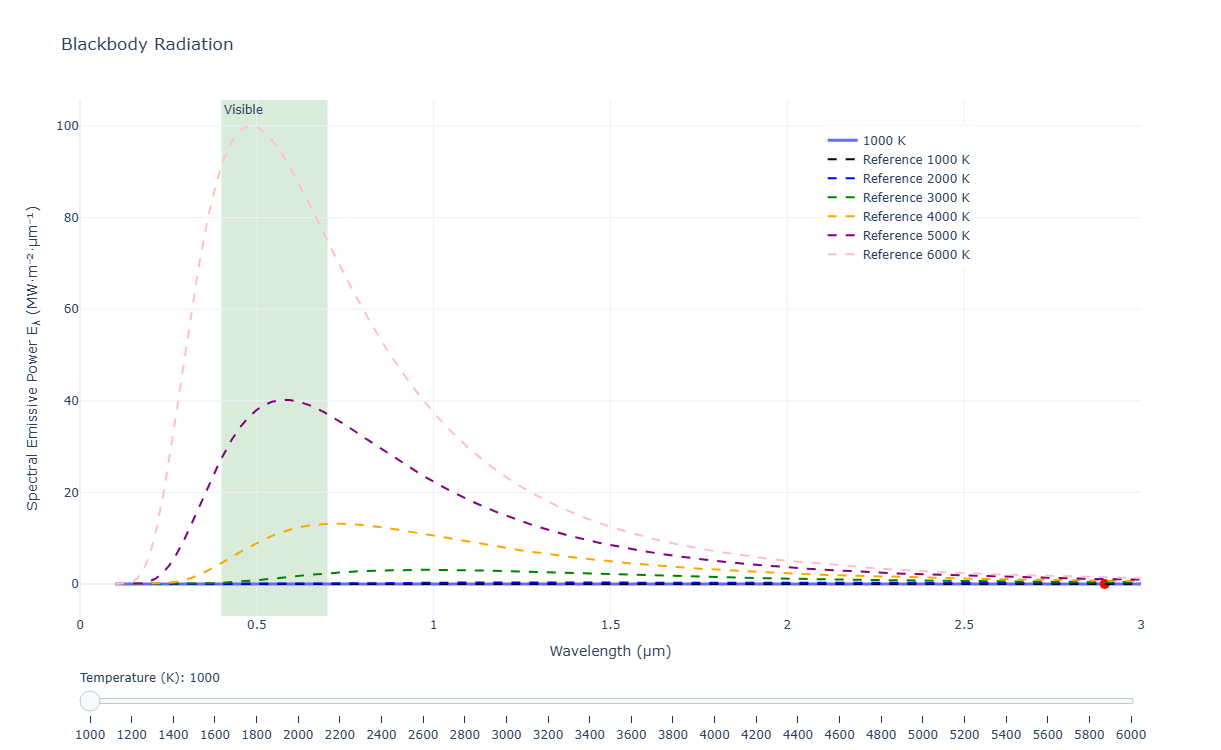

In [24]:
import numpy as np
import plotly.graph_objects as go

#####################################
#Physics class about BlackBodies#
#####################################

class BlackBody:

    h = 6.62607015e-34 #plancks constant
    c = 2.99792458e8 #speed of light
    k = 1.380649e-23 #Boltzmann constant
    sigma = 5.670374419e-8

    def __init__(self, temperature):
        self.temperature = temperature

    def planck(self, wavelength):

        T = self.temperature

        exponent = (
            self.h * self.c /
            (wavelength * self.k * T)
        )

        numerator = (
            2 * np.pi * self.h * self.c**2
        )

        denominator = (
            wavelength**5 *
            (np.exp(exponent) - 1)
        )

        return numerator / denominator * 1e-12

    def wien_peak(self):

        b = 2.897771955e-3

        return b / self.temperature

    def stefan_boltzmann(self):

        return self.sigma * self.temperature**4
###########################################################################
#Setting the ranges so all can be precomputed for static html environments#
###########################################################################
temperatures = np.arange(
    1000,
    6001,
    200
)

wavelength_um = np.linspace(
    0.1,
    3,
    3000
)

wavelength_m = wavelength_um * 1e-6

fig = go.Figure()

#####################################
#Setting tracers on graphs#
#####################################
for i, T in enumerate(temperatures):

    bb = BlackBody(T)

    E = bb.planck(wavelength_m)

    peak = bb.wien_peak() * 1e6

    visible = (i == 0)

    fig.add_trace(
        go.Scatter(
            x=wavelength_um,
            y=E,
            mode="lines",
            line=dict(width=3),
            name=f"{T} K",
            visible=visible,
            hovertemplate=
            "λ=%{x:.2f} μm<br>"
            "E=%{y:.3e}<extra></extra>"
        )
    )

    peak_index = np.argmax(E)

    fig.add_trace(
        go.Scatter(
            x=[wavelength_um[peak_index]],
            y=[E[peak_index]],
            mode="markers",
            marker=dict(
                color="red",
                size=10
            ),
            showlegend=False,
            visible=visible,
            hovertemplate=
            "Wien Peak<br>"
            "λ=%{x:.2f} μm<extra></extra>"
        )
    )

#####################################
#Set and plot reference temperatures#
#####################################
reference_temperatures = [
    1000,
    2000,
    3000,
    4000,
    5000,
    6000
]


colors = [
    "black",
    "blue",
    "green",
    "orange",
    "purple",
    "pink"
]

for T_ref, color in zip(reference_temperatures, colors):

    bb_ref = BlackBody(T_ref)

    E_ref = bb_ref.planck(wavelength_m)

    fig.add_trace(
        go.Scatter(
            x=wavelength_um,
            y=E_ref,
            mode="lines",
            line=dict(
                dash="dash",
                width=2,
                color=color
            ),
            name=f"Reference {T_ref} K",
            visible=True,
            hovertemplate=
            "Reference Curve<br>"
            f"T={T_ref} K<br>"
            "λ=%{x:.2f} μm<br>"
            "E=%{y:.3e}<extra></extra>"
        )
    )    

#####################################
#Indicating visual light wavelengths#
#####################################
fig.add_vrect(
   x0=0.4,
   x1=0.7,
   fillcolor="green",
   opacity=0.15,
   layer="below",
   line_width=0,
   annotation_text="Visible",
   annotation_position="top left"
)  

#####################################
#Main curves#
#####################################

steps = []

N = len(temperatures)

for i, T in enumerate(temperatures):

    visible = []

    # Main curves + Wien markers
    for j in range(N):

        visible.append(j == i)  # curve
        visible.append(j == i)  # marker

    # Leave reference curves untouched
    visible += [None] * len(reference_temperatures)

    step = dict(
        method="restyle",
        args=[
            {"visible": visible}
        ],
        label=str(T)
    )
#####################################
#Slider#
#####################################
    steps.append(step)
fig.update_layout(

    title="Blackbody Radiation",

    sliders=[
        dict(
            active=0,
            currentvalue={
                "prefix":
                "Temperature (K): "
            },
            pad={"t": 50},
            steps=steps
        )
    ],
    xaxis=dict(
        range=[0, 3]
    ),
    xaxis_title="Wavelength (μm)",

    yaxis_title=
    "Spectral Emissive Power E<sub>λ</sub> (MW·m⁻²·μm⁻¹)",

    template="plotly_white",

    height=750,
    autosize = True,
    
    legend=dict(
        x=0.70,
        y=0.95
    )
)
#####################################
#Show#
#####################################
fig.show(config={"responsive": True})